# EDA — Bộ Y tế (MOH)

Phân tích `moh.json`: quy mô, domain, độ phủ lịch sử xuất bản, chất lượng dữ liệu, độ dài nội dung và mẫu bài.

In [1]:
from pathlib import Path
import sys
search_roots = (Path.cwd(), *Path.cwd().parents)
module_dir = next((p for root in search_roots for p in (root, root / "loc_crawl" / "notebooks") if (p / "eda_utils.py").exists()), None)
if module_dir is None: raise FileNotFoundError("Không tìm thấy eda_utils.py")
sys.path.insert(0, str(module_dir))

from eda_utils import *
SOURCE_KEY = "moh"
df, atomic_domains, data_path = load_source(SOURCE_KEY)
print(f"Đã tải {len(df):,} bài từ {data_path}")

Đã tải 1,850 bài từ C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\moh.json


## 1. Tổng quan và mẫu dữ liệu

In [2]:
overview = source_overview(df, atomic_domains, data_path)

**File:** `C:\NC KHOA HỌC - THẦY LONG\Fact-checking\loc_crawl\output\moh.json`  
**Kích thước:** 22.30 MB

,Chỉ số,Giá trị
0,Số bài,"1,850"
1,Số domain nguyên bản,4
2,Số domain sau khi tách,4
3,Bài đa-domain,0
4,Ngày hợp lệ,"1,850 (100.0%)"
5,Ngày nhỏ nhất,2005-04-26
6,Ngày lớn nhất,2026-07-24
7,ID trùng,0
8,URL trùng,0


,id,source_name,domain,publish_date,claim,label,url
0,f7bc7933ed7857e48dea0f44aa041b05,Bộ Y tế,Tin tức - sự kiện,2026-07-24,Nâng cao chất lượng nhân lực ngành Y tế:Đổi mới công tác đào tạo đáp ứng yêu cầu mới,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=168760&cid=8355
1,6f3501446b7c26fd2846f20994b96097,Bộ Y tế,Chuyển đổi số y tế,2026-07-24,Nền tảng xây dựng bệnh viện thông minh,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=168759&cid=8430
2,f3514e07742ebbd07c0ccb9a00b26e42,Bộ Y tế,Tin tức - sự kiện,2026-07-24,Bước tiến trong điều trị dị tật sọ mặt: Mỗi ngày kéo giãn xương 1mm thay thế đại phẫu,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=168758&cid=8355
3,993ec6bb907faa437981a738370a1794,Bộ Y tế,Tra cứu,2026-07-24,"Cảnh báo lối sống ngồi nhiều, ít vận động đang âm thầm gia tăng bệnh tật",TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=168757&cid=8295
4,14862cc31d6c3004dc6d5bad006863c4,Bộ Y tế,Chuyển đổi số y tế,2026-07-24,Y học bào thai giúp bảo vệ sự sống từ trong bụng mẹ,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=168756&cid=8430


## 2. Phân bố domain

**Phân bố domain sau khi tách dấu `;`**

,domain,số_bài,tỷ_lệ_trên_bài
0,Tin tức - sự kiện,775,0.42
1,Tra cứu,571,0.31
2,Cung cấp thông tin,370,0.20
3,Chuyển đổi số y tế,134,0.07


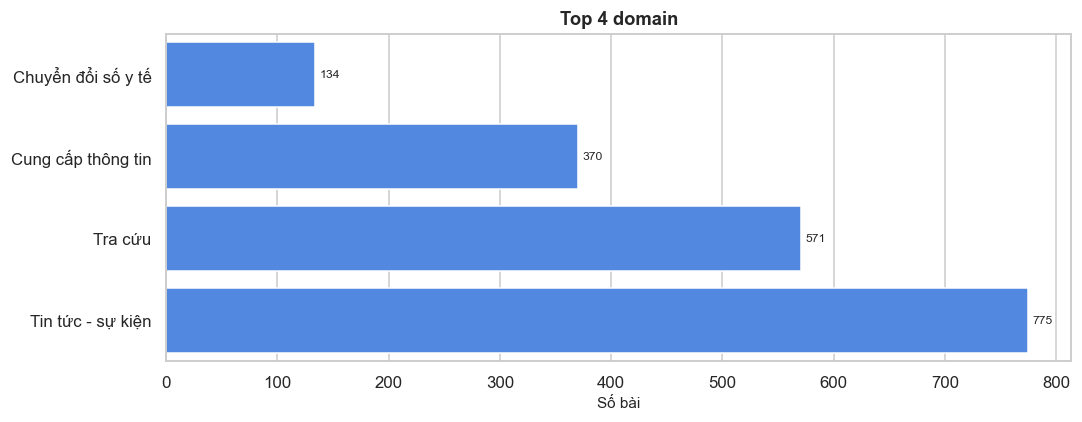

In [3]:
domain_counts = source_domain_analysis(df, atomic_domains)

## 3. Phân bố thời gian và domain theo năm

,trạng_thái_ngày,số_bài,tỷ_lệ
0,Hợp lệ,1850,1.00
1,Thiếu/không parse được,0,0.00


,year,số_bài
0,2005,25
1,2008,5
2,2009,3
3,2011,4
4,2012,3
5,2013,3
6,2014,11
7,2015,2
8,2016,8
9,2017,11


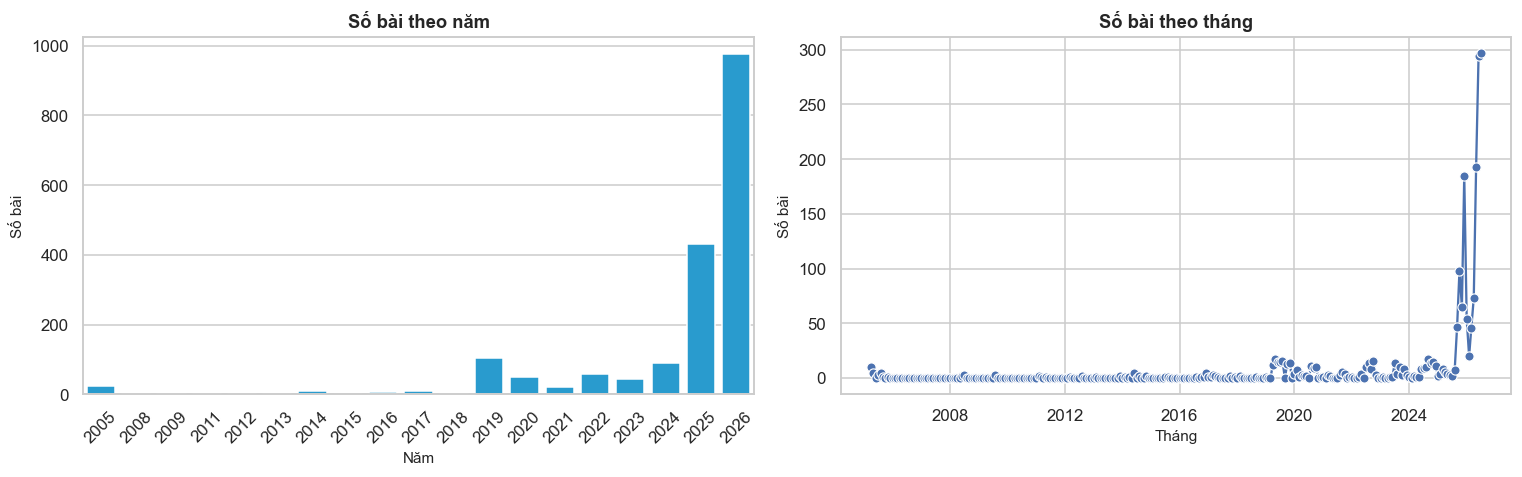

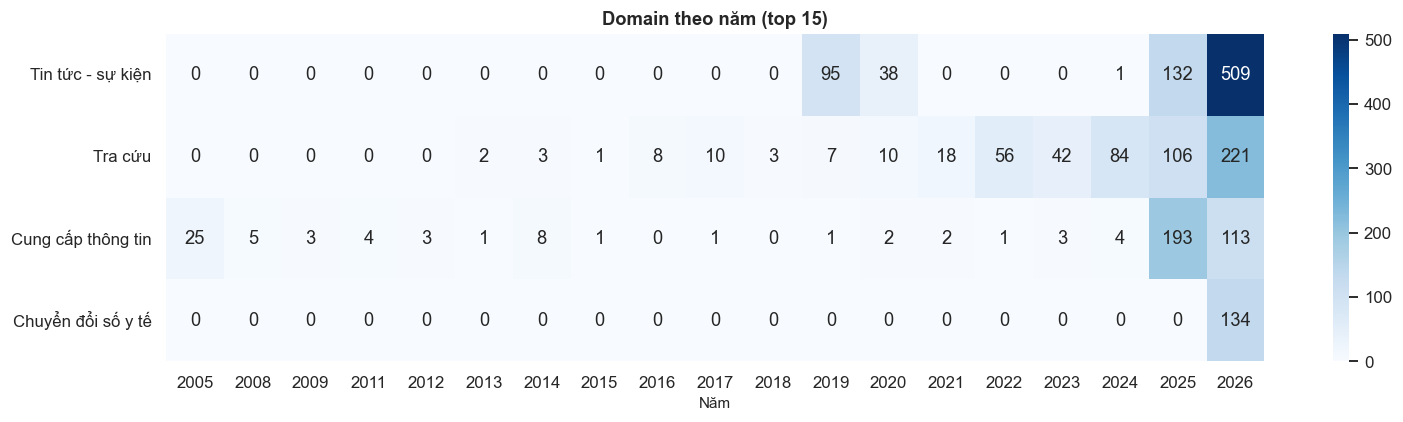

In [4]:
source_timeline(df, atomic_domains)

## 4. Chất lượng dữ liệu

,field,missing,missing_pct
0,comments,1850,100.00
1,claim,0,0.00
2,domain,0,0.00
3,evidence,0,0.00
4,id,0,0.00
5,justification,0,0.00
6,label,0,0.00
7,original_text,0,0.00
8,publish_date,0,0.00
9,source_name,0,0.00


**Trùng lặp và URL**

,khóa,số_dòng_trùng,số_giá_trị_duy_nhất
0,id,0,1850
1,url,0,1850
2,claim,59,1791
3,original_text,954,896


,chỉ_số,số_bài
0,URL HTTP(S) hợp lệ,1850
1,URL không hợp lệ/thiếu,0
2,Ngày ở tương lai so với hôm nay,0
3,Bài có comments,0


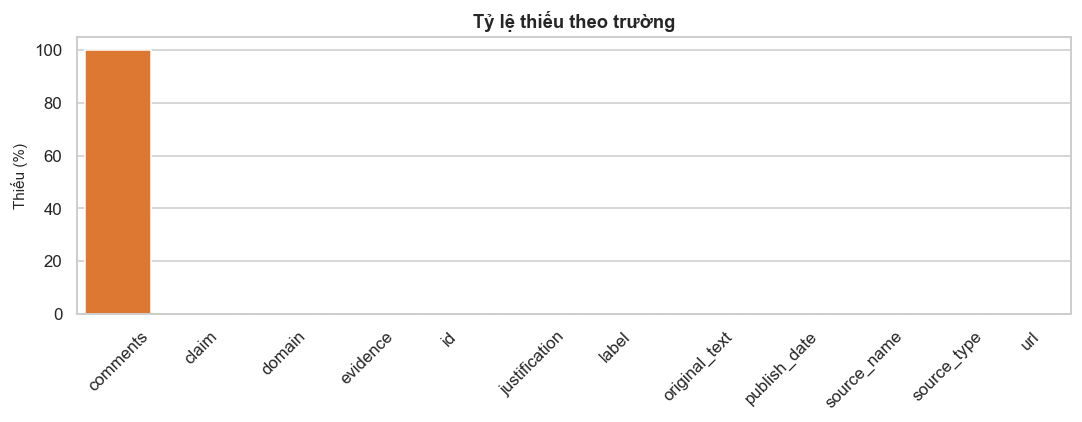

In [5]:
missing = source_quality_analysis(df)

## 5. Độ dài nội dung

,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
trường,,,,,,,,,,,
claim_words,"1,850.00",18.08,7.66,2.00,13.00,17.00,22.00,28.00,32.00,39.00,64.00
original_text_words,"1,850.00",11.44,14.34,1.00,1.00,1.00,19.00,28.00,34.00,65.00,172.00
evidence_words,"1,850.00",19.00,0.00,19.00,19.00,19.00,19.00,19.00,19.00,19.00,19.00
justification_words,"1,850.00","1,811.19","3,412.39",6.00,622.25,"1,025.00","1,455.50","2,188.30","9,037.60","18,200.91","31,374.00"


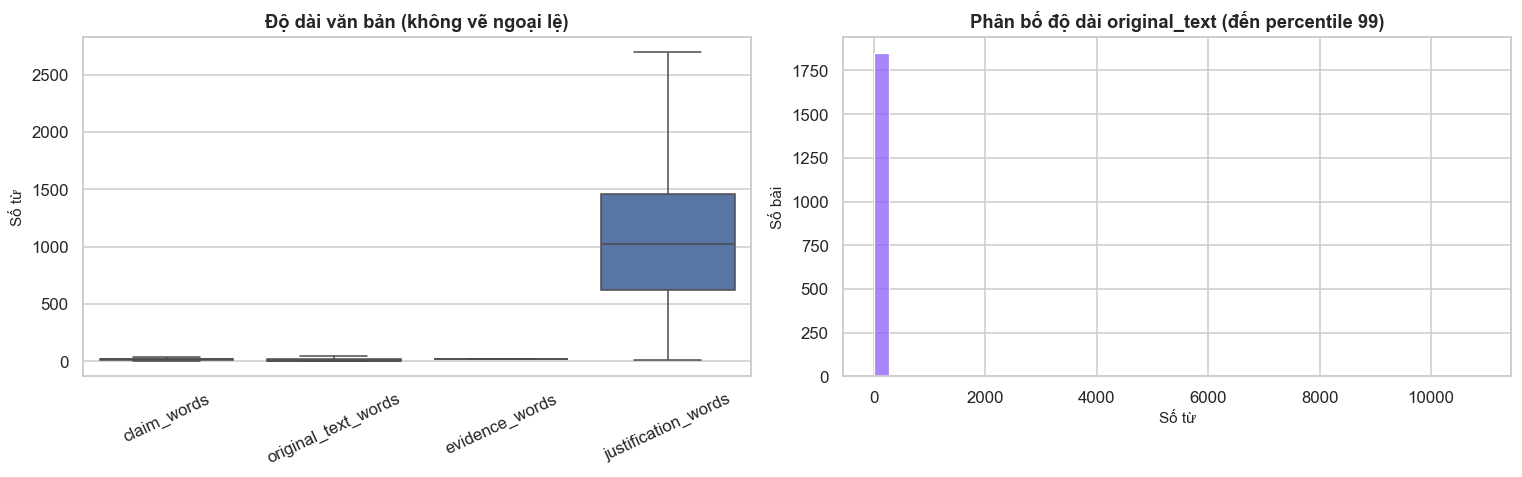

**Độ dài `original_text` theo top domain**

,số_bài,trung_vị,trung_bình,p90
domain_atomic,,,,
Chuyển đổi số y tế,134,17.00,18.38,28.00
Tin tức - sự kiện,775,14.00,13.35,29.00
Cung cấp thông tin,370,1.00,9.33,30.00
Tra cứu,571,1.00,8.58,25.00


In [6]:
text_summary = source_text_analysis(df, atomic_domains)

## 6. Nhãn, loại nguồn và hostname

In [7]:
source_metadata_analysis(df)

**Nhãn**

,label,số_bài,tỷ_lệ
0,TRUE,1850,1.00


**Loại nguồn**

,source_type,số_bài,tỷ_lệ
0,website,1850,1.00


**Tên nguồn**

,source_name,số_bài,tỷ_lệ
0,Bộ Y tế,1850,1.00


**Hostname**

,url_host,số_bài,tỷ_lệ
0,moh.gov.vn,1850,1.00


## 7. Mẫu bài theo domain và nhận xét

In [8]:
samples = source_samples(df, n_per_domain=2)
source_findings(df, atomic_domains)

,domain,publish_date,claim,label,url
0,Chuyển đổi số y tế,2026-05-05,"Hà Nội cụ thể hóa Nghị quyết số 72-NQ/TW:Khơi thông ""mạch ngầm"" y học cổ truyền",TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=167485&cid=8430
1,Chuyển đổi số y tế,2026-05-06,"TPHCM triển khai hồ sơ sức khỏe điện tử cho toàn dân, gắn mã định danh cá nhân",TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=167512&cid=8430
2,Cung cấp thông tin,2005-04-26,Injury Control,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=132049&cid=8349
3,Cung cấp thông tin,2005-04-26,Các tổ chức quốc tế đang có hoạt động về phòng chống tai nạn thương tích ở Việt Nam,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=132048&cid=8349
4,Tin tức - sự kiện,2019-04-05,Điểm tin y tế ngày 04/4/2019,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=134336&cid=8354
5,Tin tức - sự kiện,2019-04-06,Điểm tin y tế ngày 5/4/2019,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=134414&cid=8354
6,Tra cứu,2013-02-19,Thông báo Kết quả thi tuyển công chức Cục Y tế dự phòng năm 2012,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=129989&cid=8366
7,Tra cứu,2013-12-05,﻿Thông báo tuyển sinh Cao đẳng hệ chính quy năm 2013,TRUE,https://moh.gov.vn/index.jsp?pageId=5803&aid=129893&cid=8366


### Nhận xét tự động
- Có **1,850** bài và **4** domain sau khi tách.
- Domain lớn nhất là **Tin tức - sự kiện** với **775** lượt gán.
- Có **0** bài đa-domain và **0** bài thiếu/không parse được ngày.
- Phân bố nhãn: **TRUE: 1,850**.
- Các nhận xét này là mô tả dữ liệu, không phải kết luận về tính đại diện hay chất lượng nội dung.